# H1  Fragility: nominal coverage overstates resilience

**Claim under test.** Among NT communities within reach of at least one mobile tower, most
have no independent second network as backup nominal "coverage" does not imply resilience
to a single-network fault.

- **H0 (null):** redundancy is the norm at least half of covered communities have 2 or more
  independent carrier networks within 10 km, and at least half of towers carry more than one
  network.
- **H1 (alternative):** redundancy is the exception significantly less than half of covered
  communities (and of towers) have that redundancy.

**Data** (already-built pipeline outputs, not recomputed from raw sources):
`data/processed/village_gap_with_services.csv` (792 communities, `notebooks/06`/`11`) and
`data/processed/towers.csv` (431 towers, `notebooks/03`).

**Method.** Two one-sided exact binomial tests (`scipy.stats.binomtest`) against a null
proportion of 0.5 one at village level, one at tower level as an independent cross-check —
plus a chi-square test of independence between remoteness class and fragility to check whether
fragility is randomly distributed or concentrated in particular places.

**Unit of analysis -- read this before quoting a number.** A "community" here is a BushTel place,
used as a *reference point* only. Village counts are counts of places, not people: a 5-person
outstation and a 2,000-person town count once each. BushTel's own population figure is never used.
The only population in this project is the 2021 Census count per SA1, and it is never split across
the villages inside an SA1, so the population view ('Population view' section) works at SA1 level.

**Villages are not independent.** Up to 44 villages share one SA1 and often the same nearest tower,
so the textbook binomial p-value is too optimistic. A cluster bootstrap that resamples whole SA1s
(the robustness cell after the village-level test) checks that the conclusion survives without assuming independence.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import os
from pathlib import Path

if os.path.basename(os.getcwd()) == "hypothesis_proof_notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
DATA = Path("data/processed")


In [2]:
vg = pd.read_csv(DATA / "village_gap_with_services.csv", dtype={"sa1_code": str})
towers = pd.read_csv(DATA / "towers.csv")

assert vg["community_id"].is_unique and len(vg) == 792, "expected 792 unique communities"
assert towers["site_id"].is_unique and len(towers) == 431, "expected 431 unique towers"

def classify(row) -> str:
    '''Resilience tier — identical logic to app/app.py's classify(), independently
    re-derived here under the name `resilience_tier` (the pipeline's own `tier` column in
    village_gap.csv is a documented stub, all-NaN, reserved for a future T1-T5 scheme —
    see notebooks/06_village_gap.ipynb's markdown. We do not touch that column.)'''
    if row["distance_gap_candidate"] == True:
        return "beyond"            # no tower within 15 km, no guide claim of service
    if row["n_towers_10km"] == 0:
        return "spof"              # a tower exists within 15 km, but none within 10 km
    if row["n_networks_10km"] <= 1:
        return "single_net"        # towers nearby, but only one carrier among them
    return "redundant"             # 2+ independent networks within 10 km

assert vg["tier"].isna().all(), "expected the pipeline's own `tier` column to be the documented all-NaN stub"
vg["resilience_tier"] = vg.apply(classify, axis=1)
vg["resilience_tier"].value_counts().reindex(["beyond", "spof", "single_net", "redundant"])

resilience_tier
beyond        384
spof           86
single_net    221
redundant     101
Name: count, dtype: int64

## Village-level test: is redundancy the norm, or the exception, among *covered* communities?

In [3]:
covered = vg[vg["resilience_tier"] != "beyond"].copy()
n_covered = len(covered)
n_redundant = int((covered["resilience_tier"] == "redundant").sum())
n_fragile = n_covered - n_redundant

print(f"communities within reach of >=1 tower (not 'beyond'): {n_covered} of {len(vg)}")
print(f"  redundant (2+ networks within 10 km): {n_redundant}  ({n_redundant/n_covered:.1%})")
print(f"  fragile (single point of failure or single network): {n_fragile}  ({n_fragile/n_covered:.1%})")

result_v = stats.binomtest(n_redundant, n_covered, p=0.5, alternative="less")
ci_v = result_v.proportion_ci(confidence_level=0.95, method="wilson")
print()
print("H0: P(redundant | covered) = 0.5      H1: P(redundant | covered) < 0.5")
print(f"observed proportion redundant : {n_redundant/n_covered:.4f}")
print(f"95% Wilson CI (one-sided, alternative='less')    : [{ci_v.low:.4f}, {ci_v.high:.4f}]")
print(f"one-sided exact binomial p    : {result_v.pvalue:.3e}")
print("=> REJECT H0 at alpha=0.05" if result_v.pvalue < 0.05 else "=> fail to reject H0")

communities within reach of >=1 tower (not 'beyond'): 408 of 792
  redundant (2+ networks within 10 km): 101  (24.8%)
  fragile (single point of failure or single network): 307  (75.2%)

H0: P(redundant | covered) = 0.5      H1: P(redundant | covered) < 0.5
observed proportion redundant : 0.2475
95% Wilson CI (one-sided, alternative='less')    : [0.0000, 0.2843]
one-sided exact binomial p    : 1.488e-25
=> REJECT H0 at alpha=0.05


### Robustness: resample whole SA1s, not single villages

Cluster bootstrap: draw SA1s with replacement (every covered village in a drawn SA1 comes along), recompute
the share of covered villages that are redundant, 10,000 times. If the one-sided 95% upper bound stays
below 0.5, the finding does not depend on treating neighbouring villages as independent evidence.


In [4]:
rng = np.random.default_rng(42)      # fixed seed: reproducible, not cherry-picked
N_BOOT = 10_000
is_red = (covered["resilience_tier"] == "redundant").to_numpy()
sa1_groups = [np.flatnonzero(covered["sa1_code"].to_numpy() == c) for c in covered["sa1_code"].unique()]
boot = np.empty(N_BOOT)
for b in range(N_BOOT):
    pick = rng.integers(0, len(sa1_groups), len(sa1_groups))
    idx = np.concatenate([sa1_groups[i] for i in pick])
    boot[b] = is_red[idx].mean()
upper_95 = np.percentile(boot, 95)
print(f"covered villages sit in {len(sa1_groups)} SA1s")
print(f"cluster-bootstrap share redundant: {boot.mean():.3f}   one-sided 95% upper bound: {upper_95:.3f}")
print("=> still well below 0.5: conclusion holds without assuming villages are independent"
      if upper_95 < 0.5 else "=> upper bound reaches 0.5: conclusion depends on the independence assumption")


covered villages sit in 167 SA1s
cluster-bootstrap share redundant: 0.250   one-sided 95% upper bound: 0.320
=> still well below 0.5: conclusion holds without assuming villages are independent


## Tower-level cross-check (fully independent of the village join)

In [5]:
n_towers = len(towers)
n_single = int((towers["n_networks"] <= 1).sum())

result_t = stats.binomtest(n_single, n_towers, p=0.5, alternative="greater")
ci_t = result_t.proportion_ci(confidence_level=0.95, method="wilson")
print(f"towers carrying only 1 network: {n_single} of {n_towers}  ({n_single/n_towers:.1%})")
print()
print("H0: P(single-network tower) = 0.5      H1: P(single-network tower) > 0.5")
print(f"95% Wilson CI (one-sided, alternative='greater')  : [{ci_t.low:.4f}, {ci_t.high:.4f}]")
print(f"one-sided exact binomial p : {result_t.pvalue:.3e}")
print("=> REJECT H0 at alpha=0.05" if result_t.pvalue < 0.05 else "=> fail to reject H0")
print()
print("Two independent measurements (village-level network count, tower-level carrier count)",
      "agree: this is not an artefact of how the village join was built.")

towers carrying only 1 network: 331 of 431  (76.8%)

H0: P(single-network tower) = 0.5      H1: P(single-network tower) > 0.5
95% Wilson CI (one-sided, alternative='greater')  : [0.7329, 1.0000]
one-sided exact binomial p : 2.919e-30
=> REJECT H0 at alpha=0.05

Two independent measurements (village-level network count, tower-level carrier count) agree: this is not an artefact of how the village join was built.


## Is fragility randomly scattered, or does it concentrate by remoteness class?

If fragility were unrelated to remoteness, the *rate* of fragility (vs. redundancy) should be
about the same in every `remoteness_name` category. A chi-square test of independence checks
that directly.

In [6]:
covered["fragile"] = covered["resilience_tier"] != "redundant"
ct = pd.crosstab(covered["remoteness_name"], covered["fragile"])
ct.columns = ["redundant", "fragile"]
display_ct = ct.assign(fragile_rate=(ct["fragile"] / (ct["fragile"] + ct["redundant"])).round(3))
print(display_ct)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print()
print(f"chi-square test of independence: chi2={chi2:.2f}, dof={dof}, p={p_chi:.3e}")
print("=> fragility rate differs significantly by remoteness class (REJECT independence)"
      if p_chi < 0.05 else "=> no significant association with remoteness class")

                          redundant  fragile  fragile_rate
remoteness_name                                           
Outer Regional Australia         12        1         0.077
Remote Australia                 44       39         0.470
Very Remote Australia            45      267         0.856

chi-square test of independence: chi2=85.31, dof=2, p=2.990e-19
=> fragility rate differs significantly by remoteness class (REJECT independence)


## Population view Census 2021 by SA1, never split

Each SA1 that contains at least one covered village is put in one of two groups, and its whole Census
count goes with it: **no redundant village** (every covered village in the SA1 is fragile) or **has a
redundant village**. This says how many people live in SA1s where no place has a second network. It does
not claim every person in those SA1s is fragile  that would need village-level population, which the
project deliberately does not have.


In [7]:
sa1_pop = pd.read_csv(DATA / "sa1_report.csv", dtype={"sa1_code": str})[["sa1_code", "pop_census_2021"]]
sa1_status = (covered.groupby("sa1_code")["resilience_tier"]
              .apply(lambda s: "has a redundant village" if (s == "redundant").any() else "no redundant village")
              .rename("sa1_status").reset_index()
              .merge(sa1_pop, on="sa1_code", how="left", validate="1:1"))
pop_by_status = sa1_status.groupby("sa1_status").agg(n_sa1=("sa1_code", "size"), census_pop=("pop_census_2021", "sum"))
pop_by_status["share_of_pop"] = (pop_by_status["census_pop"] / pop_by_status["census_pop"].sum()).round(3)
print(pop_by_status)
pop_no_redundant = int(pop_by_status.loc["no redundant village", "census_pop"])
share_pop_no_redundant = float(pop_by_status.loc["no redundant village", "share_of_pop"])


                         n_sa1  census_pop  share_of_pop
sa1_status                                              
has a redundant village     67       16927         0.338
no redundant village       100       33177         0.662


## Visualisation

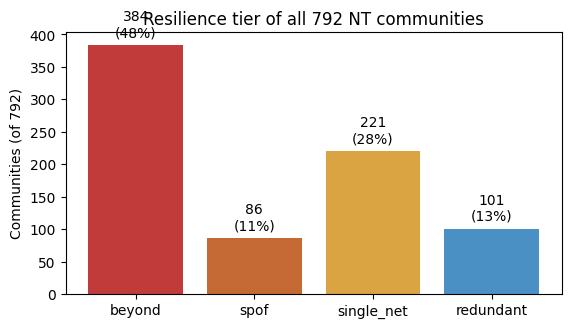

In [8]:
TIER_COLOR = {"beyond": "#C23B3B", "spof": "#C56A34", "single_net": "#D9A441", "redundant": "#4A90C4"}
order = ["beyond", "spof", "single_net", "redundant"]
counts = vg["resilience_tier"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bars = ax.bar(order, counts.values, color=[TIER_COLOR[t] for t in order])
for b, c in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, c + 8, f"{c}\n({c/len(vg):.0%})", ha="center", va="bottom")
ax.set_ylabel("Communities (of 792)")
ax.set_title("Resilience tier of all 792 NT communities")
plt.show()

## Conclusion

In [9]:
print("H1 SUMMARY")
print("=" * 60)
print(f"- {n_fragile}/{n_covered} covered BushTel places ({n_fragile/n_covered:.0%}) lack a second")
print(f"  independent network within 10 km: binomial test rejects H0 (p={result_v.pvalue:.2e}).")
print(f"  SA1-cluster bootstrap one-sided 95% upper bound on the redundant share: {upper_95:.2f} (< 0.5).")
print(f"- {n_single}/{n_towers} towers ({n_single/n_towers:.0%}) carry only one network,")
print(f"  independently confirming the finding at infrastructure level (p={result_t.pvalue:.2e}).")
print(f"- Fragility rate is {'significantly associated' if p_chi < 0.05 else 'not significantly associated'}")
print(f"  with remoteness class (chi2 p={p_chi:.2e}) -- it is not random noise.")
print(f"- Population view: {pop_no_redundant:,} people ({share_pop_no_redundant:.0%} of the Census population")
print("  in SA1s with a covered place) live in SA1s where no place has a second network.")
print()
print("=> H1 is SUPPORTED: nominal mobile 'coverage' in the NT substantially overstates real")
print("   resilience to a single-network fault. Counts above are places unless labelled as people.")


H1 SUMMARY
- 307/408 covered BushTel places (75%) lack a second
  independent network within 10 km: binomial test rejects H0 (p=1.49e-25).
  SA1-cluster bootstrap one-sided 95% upper bound on the redundant share: 0.32 (< 0.5).
- 331/431 towers (77%) carry only one network,
  independently confirming the finding at infrastructure level (p=2.92e-30).
- Fragility rate is significantly associated
  with remoteness class (chi2 p=2.99e-19) -- it is not random noise.
- Population view: 33,177 people (66% of the Census population
  in SA1s with a covered place) live in SA1s where no place has a second network.

=> H1 is SUPPORTED: nominal mobile 'coverage' in the NT substantially overstates real
   resilience to a single-network fault. Counts above are places unless labelled as people.


**Ethical note.** This finding describes *infrastructure* risk, not community deficiency 
the fragility measured here is a property of carrier network topology, not of the communities
themselves. See `docs/PROJECT_CONTEXT.md` and the project report's Discussion section for the
full ethical framing (why Indigenous population share was deliberately excluded from this and
every other analysis in this project).